# Clase 7
## Limpieza de datos

In [1]:
import seaborn as sns

import seaborn.objects as so
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sqlite3

En este trabajo exploraremos la base de datos `Sleep_Efficiency_Cleaning.csv`. Es una base descargada de kaggle.com generada a partir de información sobre los hábitos de sueño de distintas personas. La base está levemente modificada para los ejercicios de este trabajo. Las variables incluidas son:

- **ID:** identificación de participante
- **Age:** edad
- **Gender:** que designa al género de cada persona
- **Bedtime:** que tiene la hora a la que se va a dormir la persona
- **Wakeup time:** que tiene la hora a la que se despiertan las personas
- **Sleep.duration:**  que nos dice cuánto tiempo pasa cada persona durmiendo
- **Sleep.efficiency:** que nos dice cuanto del tiempo que pasan laa persona en la cama, efectivamente duermen.
- **REM sleep percentage:**  que tiene la proporción de sueño REM de la persona
- **Deep sleep percentage:**  que tiene la proporción de sueño profundo de la persona
- **Light sleep percentage:**  que tiene la proporción de sueño liviano de la persona
- **Awakenings:** que tiene la cantidad de veces que la persona se despierta a la noche
- **Caffeine consumption:** que nos dice la cantidad de cafeina que consume la persona
- **Alcohol consumption:** que nos dice la cantidad de alcohol que consume la persona
- **Smoking.status:** que nos dice si la persona es o no es fumadora
- **Excersice frequency:** que nos dice cuán frecuentemente hace ejercicio la persona

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
datos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Lic_CsdeDatos/LaboDatos/Sleep_efficiency_cleaning.csv")
datos

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
458,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
459,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
460,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


#### 1. Con lo que sabemos hasta ahora, ¿pueden detectar cosas para limpiar en los datos?

### 2. Limpieza de los datos

Nos interesará realizar algunas acciones de limpieza de datos:
- Filtrar datos
- Renombrar variables
- Eliminar datos faltantes
- Eliminar duplicados

#### 2.a. Filtrado

Veamos los histogramas de edades y duración del sueño.


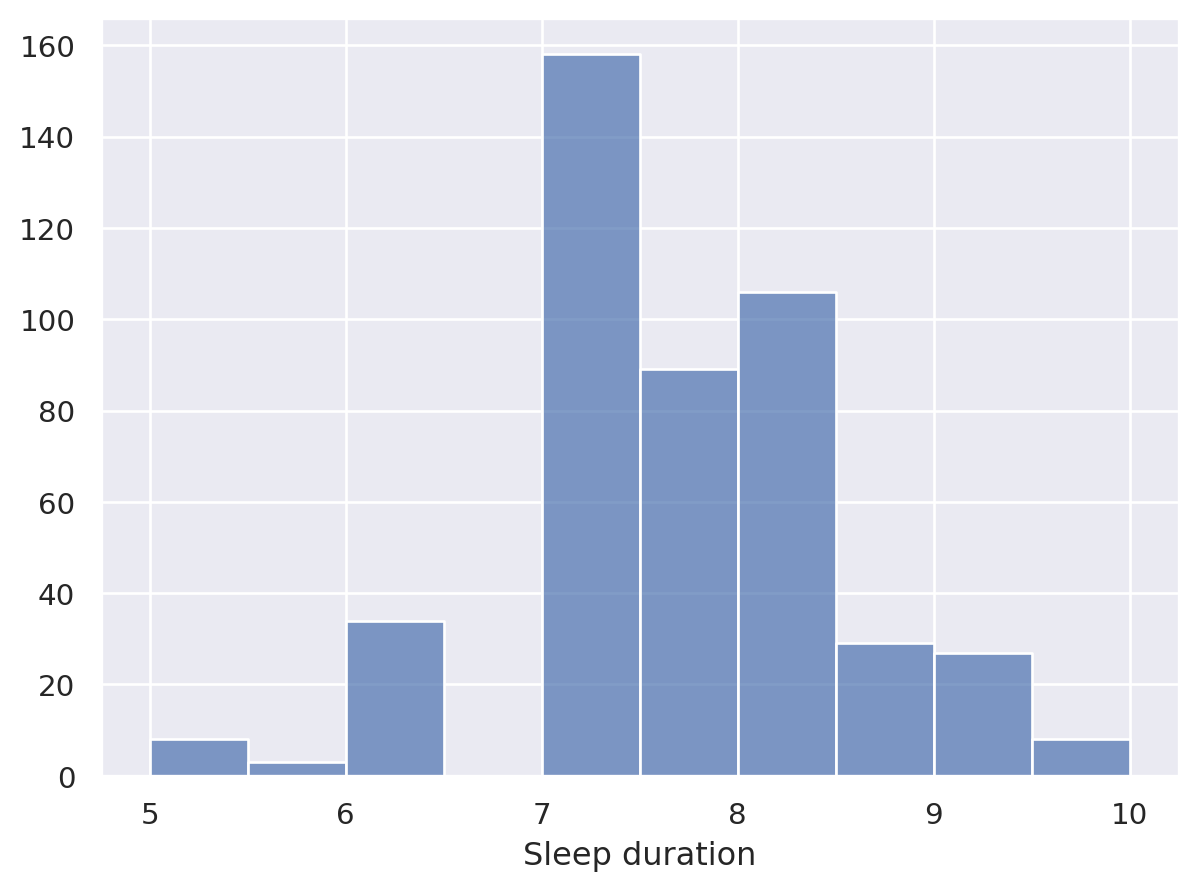

In [4]:
(
    so.Plot(datos, "Sleep duration")
    .add(so.Bars(), so.Hist(bins = 10))
)

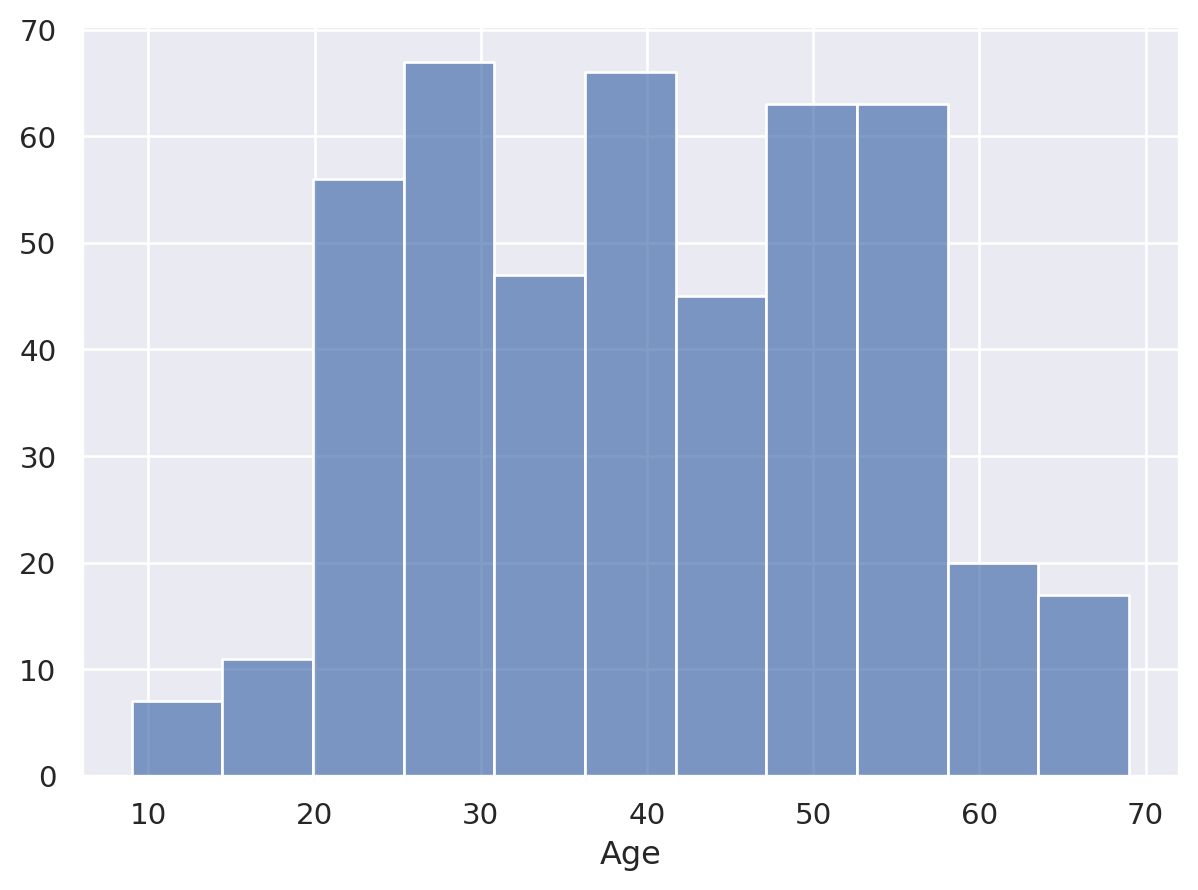

In [5]:
(
    so.Plot(datos, "Age")
    .add(so.Bars(), so.Hist())
)

En base a estos histogramas, podemos eliminar datos con valores poco frecuentes.

¿Cómo podemos sacar de los datos a los participantes menores de edad y a aquellos que hayan dormido menos de 7 horas?


In [6]:
# Filtramos datos usando SQL
con = sqlite3.connect(":memory:")   # Le damos otro nombre a la conexión, representa una conexión a otra base de datos.
datos.to_sql("sleep", con, index=False, if_exists="replace")

462

In [7]:
# Para nombres con espacios encerramos el nombre entre comillas dobles, dentro de un string las ingresamos con \"
datos = pd.read_sql_query("""
SELECT *
FROM sleep
WHERE Age >= 18 AND "Sleep duration" >= 7.0
""", con)
datos

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


### 2.b. Renombrar variables con diccionarios

Como vimos, nuestra base de datos tiene nombres de variables en inglés. Pero como nosotros somos más argentinos que usar ojotas con medias, vamos a pasarlo al castellano.

Para eso, nos van a servir mucho los **diccionarios**, que se utilizan para almacenar valores de datos en pares clave:valor.

Un diccionario es una colección ordenada, modificable y que no permite duplicados.

Yo podría generar este diccionario llamado dict

In [8]:
# Ejemplo
dict = { "hola" : "Expresión de saludo utilizada entre dos o más personas de trato familiar", "cinco" : 5, "dias" : ["lunes", "martes", "miercoles"]}

Si le pregunto que significa "hola", me dirá:

In [9]:
dict["hola"]

'Expresión de saludo utilizada entre dos o más personas de trato familiar'

In [10]:
# Ejemplo
thisdict = {
  "brand": "Ford",
  "model": "Mustang",
  "year": 1964
}
print(thisdict["brand"])

Ford


Para lo que nos interesa a nosotros, podríamos tener lo siguiente:

In [11]:
nombres = {
  "ID": "ID",
  "Age": "Edad",
  "Gender": "Género",
  "Bedtime": "Hora dormir",
  "Wakeup time": "Hora despertar",
  "Sleep duration": "Duracion suenio",
  "Sleep efficiency": "Eficiencia suenio",
  "REM sleep percentage": "Porcentaje suenio REM",
  "Deep sleep percentage": "Porcentaje suenio profundo",
  "Light sleep percentage": "Porcentaje suenio liviano",
  "Awakenings": "Despertares",
  "Caffeine consumption": "Consumo cafeina",
  "Alcohol consumption": "Consumo alcohol",
  "Smoking status": "Fumador",
  "Exercise frequency": "Frecuencia ejercicio"
}

Para cambiar los nombres deberíamos usar rename() ¿Cómo lo usarian?

Pueden chusmear la ayuda

In [12]:
help(pd.DataFrame.rename)

Help on function rename in module pandas.core.frame:

rename(self, mapper: 'Renamer | None' = None, *, index: 'Renamer | None' = None, columns: 'Renamer | None' = None, axis: 'Axis | None' = None, copy: 'bool | None' = None, inplace: 'bool' = False, level: 'Level | None' = None, errors: 'IgnoreRaise' = 'ignore') -> 'DataFrame | None'
    Rename columns or index labels.

    Function / dict values must be unique (1-to-1). Labels not contained in
    a dict / Series will be left as-is. Extra labels listed don't throw an
    error.

    See the :ref:`user guide <basics.rename>` for more.

    Parameters
    ----------
    mapper : dict-like or function
        Dict-like or function transformations to apply to
        that axis' values. Use either ``mapper`` and ``axis`` to
        specify the axis to target with ``mapper``, or ``index`` and
        ``columns``.
    index : dict-like or function
        Alternative to specifying axis (``mapper, axis=0``
        is equivalent to ``index=map

#### Syntaxis: column = function

In [13]:
datos.rename(columns = nombres)

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


In [14]:
# Funcionó?
datos

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


In [15]:
# Tenemos que asignarlo para que se guarden los cambios
datos = datos.rename(columns= nombres)
datos

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


**Pregunta:** Podemos hacer esto directamente en SQL? Sí, pero necesitamos crear la instrucción apropiada usando Python. Vamos a limitar el uso de SQL a filtrar o agregar datos.

#### Syntaxis: column = function

También podemos usar funciones para renombrar columnas.

**Ejemplo:** Pasar todos los nombres de columnas a mayúsculas.

In [16]:
# Para pasar un string a mayusculas utilizamos str.upper
str.upper("hola")


'HOLA'

In [17]:
# También
str.lower("Cómo te va?")


'cómo te va?'

¿Cómo lo usarian para renombrar nuestras variables?

In [18]:
# Así?
datos.rename(columns = str.upper)
# o así?
#datos.rename(columns = str.upper())

,ID,EDAD,GÉNERO,HORA DORMIR,HORA DESPERTAR,DURACION SUENIO,EFICIENCIA SUENIO,PORCENTAJE SUENIO REM,PORCENTAJE SUENIO PROFUNDO,PORCENTAJE SUENIO LIVIANO,DESPERTARES,CONSUMO CAFEINA,CONSUMO ALCOHOL,FUMADOR,FRECUENCIA EJERCICIO
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


Le pasamos el nombre de la función, por eso va sin los paréntesis.
Si la pasamos con paréntesis le estaríamos pasando el resultado de evaluar la función sin parámetros.

#### 2. c. Eliminar valores faltantes

¿Qué significa un valor faltante? Es un dato que por distintos motivos no fue ingresado (por ejemplo si juntamos datos de distintas fuentes, en alguna de las fuentes esa información puede no estar disponible).

Los datos faltantes son algo típico de cualquier pipeline de análisis de datos. En general los paquetes estadísticos (pandas, dplyr, etc) tratan de facilitar el manejo de estos tipos de datos. En Pandas, se utiliza la expresión NaN (Not a number) o NA que viene del mundo R (Not available)

Para poder acceder a los datos faltantes, podemos utilizar la función isna()

¿Cómo la usamos? ¿Qué nos devuelve?

In [19]:
datos.isna()

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
403,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
404,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
405,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


¿Cómo podemos transformar toda esta información para que sea más legible?

In [20]:
# Una forma bien simple sería usando
datos.isna().sum()

# De ahi sabemos que Despertares, Consumo de cafeina, Consumo de alcohol y Frecuencia de ejercicio tienen muchos datos faltantes

,0
ID,0
Edad,0
Género,0
Hora dormir,0
Hora despertar,0
Duracion suenio,0
Eficiencia suenio,0
Porcentaje suenio REM,0
Porcentaje suenio profundo,0
Porcentaje suenio liviano,0


In [21]:
# Esto nos da lo mismo (null es comun en SQL, NaN se usa en NumPy)
datos.isnull().sum()

,0
ID,0
Edad,0
Género,0
Hora dormir,0
Hora despertar,0
Duracion suenio,0
Eficiencia suenio,0
Porcentaje suenio REM,0
Porcentaje suenio profundo,0
Porcentaje suenio liviano,0


¿Qué podríamos hacer con todos estos datos faltantes?

In [22]:
# Una posibilidad es usar dropna()
# ¿Qué les parece que hace esta función?
# ¿Cuántas filas teniamos antes y cuántas tenemos ahora? ¿Cuáles son las ventajas y desventajas de esto?

datos.dropna()

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
5,11,50,Male,2021-02-28 00:30:00,2021-02-28 08:30:00,8.0,0.92,23,57,20,1.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


In [23]:
# Otra posibilidad es eliminar las columnas con datos faltantes. De forma de no perder participantes. ¿Cuáles son las ventajas y desventajas de esto?
datos.dropna(axis="columns")

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Fumador
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,Yes
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,No
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,No
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,No
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,Yes
...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,Yes
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,No
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,No
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,No


Otra opción es hacer una combinación de estas dos posibilidades. Por ejemplo, eliminar las columnas con muchos datos faltantes (e.g. Awakenings y Caffeine compsumption) y recien luego de eso eliminar las filas que tengan algun dato perdido.

De esa forma no pierdo tantas filas ni tantas columnas.

In [24]:
datos1 = datos.drop(columns=["Despertares", "Consumo cafeina"])
datos2 = datos1.dropna()
datos2

# En un rato vamos a ver que hay formas más eficientes y ordenadas de encadenar comandos como estos.

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,No,0.0


También podríamos elegir no eliminar los casos, sino reemplazar los datos faltantes con un valor (e.g. cero). A esto se lo llama "imputación de datos faltantes".

Lo podemos hacer con fillna()

In [25]:
datos.fillna(0)

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,0.0,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


¿Qué opinamos de esto? ¿Se puede usar en todos los casos? ¿Qué otras formas se te ocurren?

In [26]:
## Una forma super sencilla (pero no infalible) es reemplazar el dato perdido por la media o la mediana poblacional (Capaz la mediana es mejor porque te va a buscar un dato existente)

datos.fillna(datos.mean)

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,<bound method DataFrame.mean of ID Edad...,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


En pocas palabras:
- Completamos con 0 si pensamos que no figura el dato porque no hay o no corresponde. Por ejemplo, en información de alimentos y bebidas, el porcentaje de alcohol puede figurar como NA.
- Completamos con el promedio si pensamos que se perdió el dato y queremos afectar lo menos posible los modelos.

Cómo completarías estos datos faltantes?
- Metros cuadrados de un departamento.
- Cantidad de votos recibidos por un partido en la elección anterior.
- Cantidad de ventas realizadas de cierto producto en cierto día.
- Altura de un paciente.

### Ejercicio
1. Examinar el dataset de eficiencia MPG y hacer algo con los datos faltantes. ¿Qué harían si no queremos eliminar filas?
2. Examinar el dataset de pingüinos y hacer algo con los datos faltantes.

In [27]:
penguins = sns.load_dataset("penguins")
mpg = sns.load_dataset("mpg")

In [49]:
mpg.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
name,0


In [50]:
mpg.fillna(mpg.horsepower.mean(), inplace = True)

In [36]:
penguins.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [52]:
penguins[penguins.sex.isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


### 2.d. Eliminar datos duplicados

En muchos casos puede suceder que haya datos duplicados en nuestro dataset. ¿Se les ocurren ejemplos?

Para identificarlos, podemos usar duplicated(). ¿Qué está haciendo esta función?

In [28]:
datos.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
402,True
403,True
404,True
405,True


In [29]:
# Cuántos datos duplicados hay?
datos.duplicated().sum()

np.int64(7)

Para eliminarlos, podríamos usar  drop_duplicates()


In [30]:
datos.drop_duplicates()

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,450,40,Female,2021-09-07 23:00:00,2021-09-07 07:30:00,8.5,0.55,20,32,48,1.0,NaN,3.0,Yes,0.0
396,451,45,Male,2021-07-29 21:00:00,2021-07-29 04:00:00,7.0,0.76,18,72,10,3.0,0.0,0.0,No,3.0
397,452,18,Male,2021-03-17 02:30:00,2021-03-17 10:00:00,7.5,0.63,22,23,55,1.0,50.0,0.0,No,1.0
399,40,58,Female,2021-03-26 02:00:00,2021-03-26 09:00:00,7.0,0.63,22,23,55,3.0,50.0,3.0,No,0.0


¿Qué hace esta función? ¿Que valores se queda y cuales elimina?

Por defecto, se queda con el primer caso, pero podemos indicarle que se quede con el último por ej:

In [31]:
datos.drop_duplicates(keep = "last")

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


**Pregunta:** ¿Podemos hacerlo directo en SQL?

Si tuvieramos sujetos duplicados. Es decir, completaron dos veces la misma encuesta. como lo podríamos saber?

In [32]:
datos["ID"].duplicated().sum()

np.int64(13)

¿Y cómo los podríamos eliminar?

In [33]:
datos.drop_duplicates(subset = "ID", keep= "last")

,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Despertares,Consumo cafeina,Consumo alcohol,Fumador,Frecuencia ejercicio
0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,1.0,75.0,0.0,Yes,2.0
403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,3.0,0.0,0.0,No,3.0
404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,4.0,0.0,1.0,No,3.0
405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,50.0,0.0,No,0.0


### 2.e. Resetear el index

Una vez que eliminamos filas por el motivo que sea, nos van a quedar medio raros index. Veamos como nos quedó datos2

In [34]:
print(datos2.index)

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       396, 397, 398, 399, 401, 402, 403, 404, 405, 406],
      dtype='int64', length=387)


In [35]:
datos2.reset_index()

#Va a resetear los índices y crear una variable con los índices viejos

,index,ID,Edad,Género,Hora dormir,Hora despertar,Duracion suenio,Eficiencia suenio,Porcentaje suenio REM,Porcentaje suenio profundo,Porcentaje suenio liviano,Consumo alcohol,Fumador,Frecuencia ejercicio
0,0,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,Yes,3.0
1,1,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,0.0,No,3.0
2,2,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,No,3.0
3,3,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,No,1.0
4,4,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,Yes,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,402,197,30,Female,2021-08-05 00:00:00,2021-08-05 08:00:00,8.0,0.94,22,63,15,0.0,Yes,2.0
383,403,291,54,Male,2021-01-20 22:30:00,2021-01-20 06:30:00,8.0,0.84,18,60,22,0.0,No,3.0
384,404,102,53,Male,2021-01-28 01:00:00,2021-01-28 09:30:00,8.5,0.71,20,67,13,1.0,No,3.0
385,405,399,30,Female,2021-07-21 01:00:00,2021-07-21 08:00:00,7.0,0.91,28,52,20,0.0,No,0.0


In [ ]:
datos2.reset_index(drop=True)

# De esta forma solo nos quedamos con lo síndices nuevos.

### 3. Encadenar métodos

Esta forma de ir modificando un dataset y guardandolo cada vez en otro dataset (o en el mismo) no es muy práctica.

Por ejemplo si ejecutamos varias veces el mismo comando sin renombrar los datos, obtendremos cada vez algo distinto.

Si estamos creando un dataframe nuevo cada vez que hacemos algo, vamos a tener la memoria llena de objetos prácticamente iguales

Una solución es encadenar métodos para hacer el código más legible y fácil de reusar. Y más eficiente también.

Cada función genera un nuevo dataframe. Asi que siempre tengo que usar funciones que me generen un dataframe.

In [ ]:
datos.drop(columns=["Despertares", "Consumo cafeina"]).dropna()

¿Cómo incorporarian todo lo otro que fuimos haciendo? (eliminar también ids duplicados y resetear los índices)

### Funciones lambda


**Ejemplo:** si tenemos índices de 0 a N-1, ¿cómo podemos renumerarlos de 1 a N?

In [ ]:
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
# Una posibilidad es pasarle un nuevo vector de índices
penguins.index = penguins.index+1
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
341,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
342,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
343,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Pero esto no devuelve nada, no lo podemos encadenar con otras transformaciones.
Para encadenarlo, podemos usar rename, que funciona también para índices.

In [ ]:
# Por ejemplo, Tomamos raíz cuadradad de todos los índices
penguins.rename(index = np.sqrt)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1.000000,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1.414214,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
1.732051,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
2.236068,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
2.449490,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
18.411953,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
18.466185,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
18.493242,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
18.520259,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Para sumar uno a todos los índices no podemos hacer penguinsClean.rename(index = + 1).

Podemos definir primero nuestra propia función.

In [ ]:
def sumaUno(x):
    return(x + 1)

penguins = sns.load_dataset("penguins").dropna()
penguins.rename(index = sumaUno)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
341,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
342,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
343,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Resulta engorroso definir una función para usarla solamente dentro del rename.

Las **funciones lambda** nos permiten definir funciones anónimas "al vuelo".

La sintaxis es

`lambda arguments : expression`

In [ ]:
# Ejemplo
x = lambda a : a + 10
print(x(5))

15


In [ ]:
# Ejemplo
x = lambda a, b : a * b
print(x(5, 6))

30


In [ ]:
# Ejemplo
x = lambda a : a + 1
print(x(5))

6


In [ ]:
# Ahora sí!
penguins.rename(index = lambda a : a + 1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
341,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
342,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
343,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Esta operación la podemos encadenar con las anteriores:

In [ ]:
penguinsClean = penguins.dropna().reset_index(drop = True).rename(index = lambda a : a + 1)
penguinsClean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
# O si queremos cada metodo en una linea nueva
penguinsClean = (
    penguins.dropna()
    .reset_index(drop = True)
    .rename(index = lambda a : a + 1)
)
penguinsClean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Ejercicio:** Encadanar un método más para agregar "_orig" a los nombres de todas las columnas.

In [ ]:
penguinsClean = (
    penguins.dropna()
    .reset_index(drop = True)
    .rename(index = lambda a : a + 1)
    .rename(columns = lambda c : c.replace(c, c+'_orig'))
)
penguinsClean.head()

,species_orig,island_orig,bill_length_mm_orig,bill_depth_mm_orig,flipper_length_mm_orig,body_mass_g_orig,sex_orig
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
penguinsClean = (
    penguins.dropna()
    .reset_index(drop = True)
    .rename(index = lambda a : a + 1)
    .rename(columns = lambda c: c + '_orig')
)
penguinsClean.head()

,species_orig,island_orig,bill_length_mm_orig,bill_depth_mm_orig,flipper_length_mm_orig,body_mass_g_orig,sex_orig
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
